# Redes recurrentes

La siguiente celda contiene todos los imports necesarios para el resto de las demostraciones. El siguiente código setea a Pytorch como backend para Keras. No tiene efectos a los conceptos demostrados. Por defecto, Keras utiliza Tensorflow.

```python
os.environ["KERAS_BACKEND"] = "torch"
```

In [2]:
import os
# This guide can only be run with the torch backend.
os.environ["KERAS_BACKEND"] = "torch"

# Si el entorno no tiene torch/keras instalados, los instala (kernel nuevo, venv local
# limpio, etc.). El chequeo de keras va DESPUES de fijar KERAS_BACKEND: si keras se
# importa antes de esa variable, queda pegado al backend por defecto y el resto de la
# notebook (que asume tensores de torch) rompe.
try:
    import keras  # noqa: F401
except ImportError:
    %pip install -q "keras>=3.0.0"
try:
    import torch  # noqa: F401
except ImportError:
    %pip install -q torch
try:
    import tensorflow  # noqa: F401  -- dependencia interna de Keras 3 (tree/optree), aunque el backend sea torch
except ImportError:
    %pip install -q tensorflow-cpu


from matplotlib import pyplot as plt
import numpy as np
import torch
from keras.layers import LSTM, SimpleRNN, Bidirectional, Dense, Input, RepeatVector, Dropout, Dense, \
                        Embedding, Add, Dot, Reshape
from keras.models import Model
from keras.utils import plot_model
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import LambdaCallback
from keras.optimizers import RMSprop
from keras.utils import get_file
from keras import backend as K
from keras import ops

from IPython.display import Image
from sklearn.utils import shuffle
from collections import Counter, deque
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from collections import defaultdict
import random
import sys
import io

#Baja los stopwords
nltk.download('stopwords')
stop = stopwords.words('english')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Vanishing Gradient en una RNN simple 📉

---
Vamos a hacer tres cosas:
1. Medir directamente cuánto se **encoge el gradiente** de la salida `h_T` respecto de la entrada del primer paso `x_1`, a medida que crece `T` — es la cuenta de la Slide 11 (potencia de matrices/Jacobiano) hecha con números reales, sobre una RNN sin entrenar (nos interesa el efecto puramente estructural del largo de la secuencia, no el entrenamiento en sí).
2. Ver la consecuencia práctica: entrenar una `SimpleRNN` en una tarea de juguete donde la respuesta depende **solo del primer elemento** de la secuencia, y comparar qué pasa con secuencias largas vs. cortas.
3. Repetir exactamente la misma medición del punto 1, pero con una GRU en vez de una RNN simple — para ver, con números, que las compuertas evitan el problema.

In [4]:
def gradiente_primer_paso(seq_len, hidden_size=16, input_size=1, seed=0, w_in=0.5, w_rec=0.15):
    """Mide ||d h_T / d x_1|| en una RNN simple sin entrenar (solo forward + backward),
    para aislar el efecto puramente estructural del largo de la secuencia. w_rec se
    elige chico a propósito para que el radio espectral de Wh sea < 1 (la condición
    de "vanishing" de la Slide 11) -- con pesos recurrentes más grandes la misma
    cuenta puede terminar en el régimen de exploding en vez de vanishing."""
    g = torch.Generator().manual_seed(seed)
    Wx = torch.randn(hidden_size, input_size, generator=g) * w_in
    Wh = torch.randn(hidden_size, hidden_size, generator=g) * w_rec
    b = torch.zeros(hidden_size)

    x = torch.randn(seq_len, input_size, generator=g, requires_grad=True)
    h = torch.zeros(hidden_size)
    for t in range(seq_len):
        h = torch.tanh(Wx @ x[t] + Wh @ h + b)

    h.sum().backward()
    return x.grad[0].norm().item()


def gradiente_promedio(fn, seq_len, n_seeds=10, **kwargs):
    """Promedia ||d h_T/d x_1|| sobre varias inicializaciones al azar. Usamos
    promedio geométrico (promedio de los logaritmos): estas normas son muy
    asimétricas -- unos pocos seeds con transitorios grandes pueden dominar un
    promedio aritmético y esconder la tendencia típica."""
    vals = [fn(seq_len, seed=s, **kwargs) for s in range(n_seeds)]
    log_mean = sum(np.log(v + 1e-300) for v in vals) / len(vals)
    return float(np.exp(log_mean))


print(f"{'seq_len':>8} | ||d h_T / d x_1||  (promedio geométrico sobre 10 inicializaciones)")
for seq_len in [5, 10, 20, 50, 100, 200]:
    g = gradiente_promedio(gradiente_primer_paso, seq_len)
    print(f"{seq_len:>8} | {g:.2e}")

 seq_len | ||d h_T / d x_1||  (promedio geométrico sobre 10 inicializaciones)
       5 | 3.11e-02
      10 | 1.34e-03
      20 | 2.50e-06
      50 | 4.63e-14
     100 | 2.27e-27
     200 | 8.40e-222


El gradiente que le llega al primer paso se encoge exponencialmente con `T` — es exactamente la cuenta de la Slide 11: en cada paso hacia atrás se multiplica (aproximadamente) por el mismo Jacobiano, y si su radio espectral es menor a 1, el producto tiende a 0. Promediamos sobre 10 inicializaciones al azar (`gradiente_promedio`) porque una sola RNN sin entrenar puede tener transitorios grandes de una corrida a otra — lo que importa acá es la tendencia general, no el valor puntual de un seed. Con `T=200` el gradiente que llega a `x_1` es cero en punto flotante: **no queda señal de aprendizaje** para lo que pasó al principio de la secuencia.

### La consecuencia práctica: una tarea donde solo importa el primer paso

Dataset sintético: secuencias de bits al azar, donde la etiqueta es **el primer bit** de la secuencia (el resto son bits irrelevantes, puro ruido). Para acertar, la red tiene que "recordar" `x_1` hasta el final — literalmente la misma cuenta de arriba, pero ahora puesta a prueba entrenando de verdad.

In [5]:
def dataset_recordar_primer_bit(n_samples, seq_len, seed=None):
    rng = np.random.RandomState(seed)
    x = rng.randint(0, 2, size=(n_samples, seq_len, 1)).astype('float32')
    y = x[:, 0, 0].copy()  # la etiqueta es el primer bit; el resto de la secuencia es ruido
    return x, y


def entrenar_rnn_simple(seq_len, epochs=15):
    x_train, y_train = dataset_recordar_primer_bit(400, seq_len, seed=0)
    x_val, y_val = dataset_recordar_primer_bit(100, seq_len, seed=1)

    i = Input((seq_len, 1))
    d = SimpleRNN(16)(i)
    d = Dense(1, activation='sigmoid')(d)
    model = Model(i, d)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model.fit(x_train, y_train, validation_data=(x_val, y_val),
                      epochs=epochs, batch_size=64, verbose=0)


hist_larga = entrenar_rnn_simple(seq_len=100)
hist_corta = entrenar_rnn_simple(seq_len=10)

print('Secuencia larga (T=100) - accuracy val final:', hist_larga.history['val_accuracy'][-1])
print('Secuencia corta (T=10)  - accuracy val final:', hist_corta.history['val_accuracy'][-1])

Secuencia larga (T=100) - accuracy val final: 0.5400000214576721
Secuencia corta (T=10)  - accuracy val final: 1.0


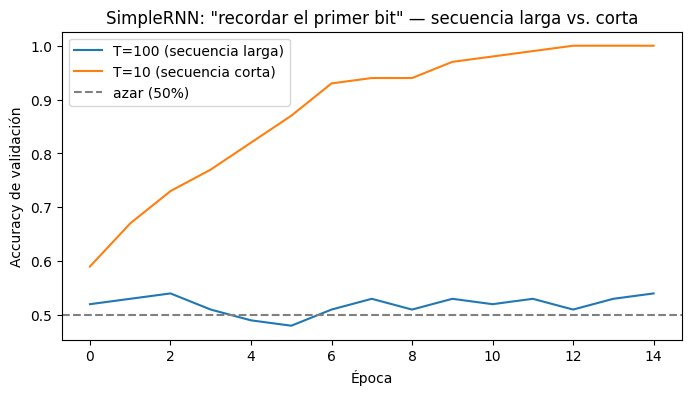

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(hist_larga.history['val_accuracy'], label='T=100 (secuencia larga)')
plt.plot(hist_corta.history['val_accuracy'], label='T=10 (secuencia corta)')
plt.axhline(0.5, color='gray', linestyle='--', label='azar (50%)')
plt.xlabel('Época')
plt.ylabel('Accuracy de validación')
plt.title('SimpleRNN: "recordar el primer bit" — secuencia larga vs. corta')
plt.legend()
plt.show()

**La secuencia larga se queda pegada en ~50% (azar): la `SimpleRNN` nunca logra propagar el gradiente 100 pasos hacia atrás para aprender que `x_1` importa.** La secuencia corta sí converge — con solo 10 pasos, el gradiente todavía llega con señal utilizable al primer paso.

**Una "solución" (parcial, y con trade-offs) es literalmente achicar la secuencia**: partir el texto en ventanas más cortas, resumir/truncar antes de meterlo a la RNN, o usar un stride mayor. Achicar la secuencia funciona, pero tiene un costo obvio: se pierde exactamente el contexto de largo alcance que no entraba en la ventana — no es gratis, y no escala a tareas donde la dependencia relevante es genuinamente larga (como el Bloque 5, con reseñas de cientos de palabras).

La solución real — que no sacrifica el largo de la secuencia — son las arquitecturas con compuertas que vemos a continuación: GRU y LSTM.

Todavía no vimos en las diapositivas cómo está armada la GRU por dentro (eso viene ahora) — pero aprovechamos que tenemos el experimento de gradiente recién armado para adelantar el resultado: **¿qué pasa si repetimos exactamente la misma medición reemplazando la RNN simple por una GRU?**

In [7]:
def gradiente_primer_paso_gru(seq_len, hidden_size=16, input_size=1, seed=0, w_in=0.5, w_rec=0.15, bias_z=-6.0):
    """Igual que gradiente_primer_paso, pero con una GRU manual (compuertas r, z
    y estado candidato h_tilde). Sesgamos la compuerta de actualizacion z para
    que arranque muy cerca de 0 (sigmoid(bias_z) chico): asi (1 - z_t) queda cerca
    de 1 y el estado viejo se propaga casi directo, sin pasar por una
    no-linealidad en cascada -- el "camino directo" que van a ver en la Slide 12."""
    g = torch.Generator().manual_seed(seed)

    def rand_in(*shape):
        return torch.randn(*shape, generator=g) * w_in

    def rand_rec(*shape):
        return torch.randn(*shape, generator=g) * w_rec

    Wr, Ur, br = rand_in(hidden_size, input_size), rand_rec(hidden_size, hidden_size), torch.zeros(hidden_size)
    Wz, Uz, bz = rand_in(hidden_size, input_size), rand_rec(hidden_size, hidden_size), torch.full((hidden_size,), bias_z)
    Wh, Uh, bh = rand_in(hidden_size, input_size), rand_rec(hidden_size, hidden_size), torch.zeros(hidden_size)

    x = torch.randn(seq_len, input_size, generator=g, requires_grad=True)
    h = torch.zeros(hidden_size)
    for t in range(seq_len):
        r = torch.sigmoid(Wr @ x[t] + Ur @ h + br)
        z = torch.sigmoid(Wz @ x[t] + Uz @ h + bz)
        h_tilde = torch.tanh(Wh @ x[t] + Uh @ (r * h) + bh)
        h = (1 - z) * h + z * h_tilde

    h.sum().backward()
    return x.grad[0].norm().item()


print(f"{'seq_len':>8} | ||d h_T/d x_1||  SimpleRNN | ||d h_T/d x_1||  GRU")
for seq_len in [5, 10, 20, 50, 100, 200]:
    g_rnn = gradiente_promedio(gradiente_primer_paso, seq_len)
    g_gru = gradiente_promedio(gradiente_primer_paso_gru, seq_len)
    print(f"{seq_len:>8} | {g_rnn:>24.2e} | {g_gru:>18.2e}")

 seq_len | ||d h_T/d x_1||  SimpleRNN | ||d h_T/d x_1||  GRU
       5 |                 3.11e-02 |           3.08e-03
      10 |                 1.34e-03 |           3.05e-03
      20 |                 2.50e-06 |           1.85e-03
      50 |                 4.63e-14 |           1.80e-03
     100 |                 2.27e-27 |           1.57e-03
     200 |                8.40e-222 |           1.16e-03


**Ahí está el contraste**: el gradiente promedio de la RNN simple colapsa a cero en punto flotante mucho antes de `T=200` (elegimos `w_rec` chico justo para que esto pase de forma limpia); el de la GRU apenas cae de ~3×10⁻³ a ~1×10⁻³ en el mismo rango — se achica, pero **un factor ~3, no un factor ~10²⁰⁰**. Tampoco explota: `(1 - z_t)` está siempre entre 0 y 1, así que ese factor nunca puede crecer sin control como sí puede pasar con el Jacobiano de la RNN simple.

*Nota honesta:* esto no es gratis ni mágico — lo conseguimos porque sesgamos a propósito la compuerta `z` para que arranque muy cerca de 0 (`bias_z = -6`), favoreciendo el "camino directo" `(1 - z_t) ⊙ h_{t-1}`. Durante el entrenamiento real la red **aprende** cuándo conviene que `z_t` sea chico (para preservar información vieja) y cuándo conviene que sea grande (para incorporar información nueva) — acá simplemente elegimos el sesgo inicial que hace explícito *por qué* la arquitectura puede resolver el problema, antes de ver en las diapositivas cómo están armadas las compuertas por dentro.

Antes de ir a las diapositivas, un experimento más en la misma línea — esta vez sobre otra propiedad estructural (no vanishing gradient, sino qué información está disponible en cada paso): RNN bidireccional.

## RNN Bidireccional: ver ambos lados de la secuencia 👀

En la Slide 14 van a ver la idea: correr dos RNN en paralelo, una hacia adelante y otra hacia atrás, y combinar los dos estados. Antes de eso, un experimento que aísla exactamente qué compra esto — y qué **no** compra.

**Tarea de juguete:** secuencias de bits al azar. La etiqueta en cada posición `t` es `1` si `x_t` es igual al **último bit de la secuencia** (`x_{T-1}`), `0` si no. Con bits al azar la etiqueta queda balanceada 50/50 — "azar" da 50% de accuracy, igual que en el experimento del Bloque 2.

¿Por qué es imposible para una RNN unidireccional? En el paso `t`, la red solo vio `x_1, ..., x_t` — todavía no tiene forma de saber cuál es `x_{T-1}` (salvo, claro, en la última posición, donde `x_t` y `x_{T-1}` son literalmente el mismo bit). No es que le cueste más: **estructuralmente no tiene la información** hasta que llega al final.

In [10]:
def dataset_igual_al_ultimo(n_samples, seq_len, seed=None):
    """Secuencias de bits al azar. Etiqueta por posicion: y_t = 1 si x_t es igual
    al ULTIMO bit de la secuencia (x_{T-1}), 0 si no. Con bits al azar la
    etiqueta queda balanceada 50/50 -- "azar" da 50% de accuracy."""
    rng = np.random.RandomState(seed)
    x = rng.randint(0, 2, size=(n_samples, seq_len, 1)).astype('float32')
    y = (x[:, :, 0] == x[:, -1, 0:1]).astype('float32')[..., np.newaxis]
    return x, y


def entrenar_igual_al_ultimo(seq_len, bidireccional, epochs=15):
    x_train, y_train = dataset_igual_al_ultimo(2000, seq_len, seed=0)
    x_val, y_val = dataset_igual_al_ultimo(500, seq_len, seed=1)

    capa_recurrente = LSTM(16, return_sequences=True)
    if bidireccional:
        capa_recurrente = Bidirectional(capa_recurrente)

    i = Input((seq_len, 1))
    d = capa_recurrente(i)
    d = Dense(1, activation='sigmoid')(d)
    model = Model(i, d)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model.fit(x_train, y_train, validation_data=(x_val, y_val),
                      epochs=epochs, batch_size=64, verbose=0)


hist_uni = entrenar_igual_al_ultimo(seq_len=15, bidireccional=False)
hist_bi = entrenar_igual_al_ultimo(seq_len=15, bidireccional=True)

print('Unidireccional - accuracy val final:', hist_uni.history['val_accuracy'][-1])
print('Bidireccional   - accuracy val final:', hist_bi.history['val_accuracy'][-1])

Unidireccional - accuracy val final: 0.536133348941803
Bidireccional   - accuracy val final: 0.9534666538238525


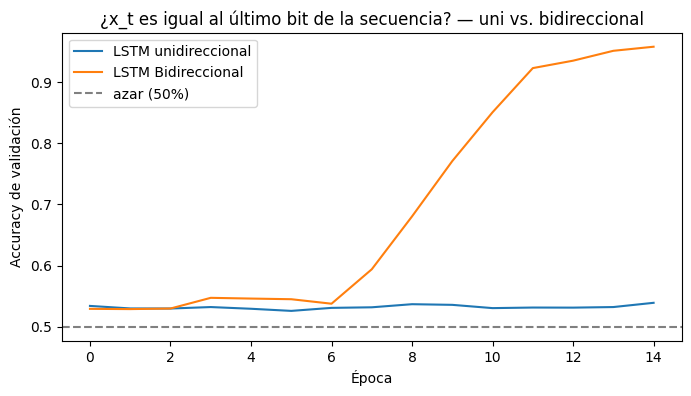

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(hist_uni.history['val_accuracy'], label='LSTM unidireccional')
plt.plot(hist_bi.history['val_accuracy'], label='LSTM Bidireccional')
plt.axhline(0.5, color='gray', linestyle='--', label='azar (50%)')
plt.xlabel('Época')
plt.ylabel('Accuracy de validación')
plt.title('¿x_t es igual al último bit de la secuencia? — uni vs. bidireccional')
plt.legend()
plt.show()

**El unidireccional se queda pegado apenas por encima del azar** (~53-54%: solo acierta "gratis" en la última posición, que siempre coincide consigo misma) — no por falta de entrenamiento, sino porque la información que necesita todavía no llegó cuando tiene que predecir. **El bidireccional resuelve la tarea** (por encima del 90% en pocas épocas): su pasada hacia atrás arranca literalmente en `x_{T-1}`, así que esa información está disponible desde el primer paso de la pasada hacia adelante también.

En Keras es una línea: `Bidirectional(LSTM(16, return_sequences=True))` envuelve la capa recurrente y se encarga de las dos pasadas y de concatenar los estados.

**Lo que NO compra:** este mismo truco es inaplicable a generación autoregresiva — no existe un `x_{T-1}` para leer de antemano cuando el modelo todavía no generó el texto. Por eso el generador de texto del Bloque 7 es unidireccional a propósito. Donde sí aplica de lleno es en tareas como el Bloque 5 (IMDB): ahí también tenemos la reseña completa disponible *antes* de clasificar, aunque esa sección sigue usando LSTM simple por simplicidad — envolverla en `Bidirectional` queda como ejercicio.

Vamos a las diapositivas a ver GRU, LSTM y Bidireccional en detalle — y después sí, a programar el primer modelo con estas piezas.

## Sumando con RNNs ➕

Este fragmento de código genera un conjunto de datos sintéticos para entrenar una red neuronal recurrente en la tarea de realizar sumas de números representados como texto. Primero define una clase CharacterTable que convierte caracteres en codificaciones one-hot y viceversa, lo cual es útil para alimentar la red con entradas y salidas codificadas. Luego, se crean pares de números aleatorios con hasta DIGITS cifras, se evita repetir sumas conmutativas (por ejemplo, `12+3` y `3+12`) y se asegura que todas las entradas tengan una longitud fija (`MAXLEN`) mediante padding con espacios. Las sumas también se almacenan como cadenas con padding para asegurar longitud uniforme, y opcionalmente se puede invertir el orden de las entradas. Este dataset sirve como un problema de juguete para que una RNN aprenda a mapear secuencias de texto que representan sumas hacia sus resultados.



In [ ]:
TRAINING_SIZE = 50000
DIGITS = 3
REVERSE = False
MAXLEN = DIGITS + 1 + DIGITS

class CharacterTable:
    """Given a set of characters:
    + Encode them to a one-hot integer representation
    + Decode the one-hot or integer representation to their character output
    + Decode a vector of probabilities to their character output
    """

    def __init__(self, chars):
        """Initialize character table.
        # Arguments
            chars: Characters that can appear in the input.
        """
        self.chars = sorted(set(chars))
        self.char_indices = dict((c, i) for i, c in enumerate(self.chars))
        self.indices_char = dict((i, c) for i, c in enumerate(self.chars))

    def encode(self, C, num_rows):
        """One-hot encode given string C.
        # Arguments
            C: string, to be encoded.
            num_rows: Number of rows in the returned one-hot encoding. This is
                used to keep the # of rows for each data the same.
        """
        x = np.zeros((num_rows, len(self.chars)))
        for i, c in enumerate(C):
            x[i, self.char_indices[c]] = 1
        return x

    def decode(self, x, calc_argmax=True):
        """Decode the given vector or 2D array to their character output.
        # Arguments
            x: A vector or a 2D array of probabilities or one-hot representations;
                or a vector of character indices (used with `calc_argmax=False`).
            calc_argmax: Whether to find the character index with maximum
                probability, defaults to `True`.
        """
        if calc_argmax:
            x = x.argmax(axis=-1)
        return "".join(self.indices_char[x] for x in x)


# All the numbers, plus sign and space for padding.
chars = "0123456789+ "
ctable = CharacterTable(chars)
questions = []
expected = []
seen = set()
print("Generating data...")
while len(questions) < TRAINING_SIZE:
    f = lambda: int(
        "".join(
            np.random.choice(list("0123456789"))
            for i in range(np.random.randint(1, DIGITS + 1))
        )
    )
    a, b = f(), f()
    # Skip any addition questions we've already seen
    # Also skip any such that x+Y == Y+x (hence the sorting).
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    # Pad the data with spaces such that it is always MAXLEN.
    q = "{}+{}".format(a, b)
    query = q + " " * (MAXLEN - len(q))
    ans = str(a + b)
    # Answers can be of maximum size DIGITS + 1.
    ans += " " * (DIGITS + 1 - len(ans))
    if REVERSE:
        # Reverse the query, e.g., '12+345  ' becomes '  543+21'. (Note the
        # space used for padding.)
        query = query[::-1]
    questions.append(query)
    expected.append(ans)
print("Total questions:", len(questions))

Generating data...
Total questions: 50000


In [ ]:
# Mostrar 10 ejemplos aleatorios del dataset generado
for i in range(10):
    idx = random.randint(0, len(questions) - 1)
    print(f"Ejemplo {i+1}:")
    print("Pregunta :", questions[idx])
    print("Respuesta:", expected[idx])
    print("-" * 30)

Ejemplo 1:
Pregunta : 785+622
Respuesta: 1407
------------------------------
Ejemplo 2:
Pregunta : 685+7  
Respuesta: 692 
------------------------------
Ejemplo 3:
Pregunta : 80+837 
Respuesta: 917 
------------------------------
Ejemplo 4:
Pregunta : 71+138 
Respuesta: 209 
------------------------------
Ejemplo 5:
Pregunta : 891+341
Respuesta: 1232
------------------------------
Ejemplo 6:
Pregunta : 20+341 
Respuesta: 361 
------------------------------
Ejemplo 7:
Pregunta : 243+8  
Respuesta: 251 
------------------------------
Ejemplo 8:
Pregunta : 630+14 
Respuesta: 644 
------------------------------
Ejemplo 9:
Pregunta : 96+230 
Respuesta: 326 
------------------------------
Ejemplo 10:
Pregunta : 758+547
Respuesta: 1305
------------------------------


Este bloque de código realiza la **vectorización** del dataset textual para que pueda ser procesado por una red neuronal. Primero, cada pregunta (`questions`) y su respuesta correspondiente (`expected`) se convierte en una representación *one-hot* de tamaño fijo mediante la clase `CharacterTable`, y se almacenan en las matrices `x` e `y`. Luego, los datos se barajan aleatoriamente usando `np.random.shuffle` para evitar que la red aprenda patrones basados en el orden secuencial de los datos generados (por ejemplo, sumas con números pequeños al inicio). Posteriormente, se separa explícitamente un **10% del conjunto como datos de validación**, asegurando que estas muestras no se utilicen durante el entrenamiento. El conjunto se divide en `x_train`/`y_train` para entrenamiento y `x_val`/`y_val` para validación. Finalmente, se imprime la forma de estos conjuntos para verificar que la preparación del dataset se ha realizado correctamente.


In [ ]:
print("Vectorization...")
x = np.zeros((len(questions), MAXLEN, len(chars)), dtype=bool)
y = np.zeros((len(questions), DIGITS + 1, len(chars)), dtype=bool)
for i, sentence in enumerate(questions):
    x[i] = ctable.encode(sentence, MAXLEN)
for i, sentence in enumerate(expected):
    y[i] = ctable.encode(sentence, DIGITS + 1)
# Shuffle (x, y) in unison as the later parts of x will almost all be larger
# digits.
indices = np.arange(len(y))
np.random.shuffle(indices)
x = x[indices]
y = y[indices]

# Explicitly set apart 10% for validation data that we never train over.
split_at = len(x) - len(x) // 10
(x_train, x_val) = x[:split_at], x[split_at:]
(y_train, y_val) = y[:split_at], y[split_at:]

print("Training Data:")
print(x_train.shape)
print(y_train.shape)

print("Validation Data:")
print(x_val.shape)
print(y_val.shape)

Vectorization...
Training Data:
(45000, 7, 12)
(45000, 4, 12)
Validation Data:
(5000, 7, 12)
(5000, 4, 12)


Este código define y compila una **red neuronal recurrente (RNN)** utilizando Keras para resolver sumas representadas como secuencias de caracteres. La arquitectura comienza con una capa de entrada `Input` que espera una secuencia de longitud `MAXLEN`, donde cada carácter está codificado en formato *one-hot* de tamaño `len(chars)`. Luego se aplica una capa `LSTM` con 128 unidades que procesa la secuencia y produce un vector de contexto fijo (`return_sequences=False`). Este vector se repite `DIGITS+1` veces mediante `RepeatVector` para coincidir con la longitud de la secuencia de salida (la suma). A continuación, una segunda capa `LSTM` con `return_sequences=True` genera una salida en cada paso de tiempo. Finalmente, una capa `Dense` con activación `softmax` predice la probabilidad de cada carácter posible en cada posición de la salida. El modelo se compila usando la pérdida `categorical_crossentropy`, el optimizador `adam` y se entrena evaluando la métrica de precisión (`accuracy`). La función `model.summary()` imprime una descripción de la arquitectura.

### LSTM: Explicación Matemática 🧑‍🏫

Las LSTM son un tipo de red neuronal recurrente (RNN) diseñada para aprender dependencias a largo plazo en secuencias. Su arquitectura introduce **puertas** que controlan el flujo de información a través del tiempo. Cada celda LSTM mantiene un **estado interno** (memoria a largo plazo) y una **salida oculta**.

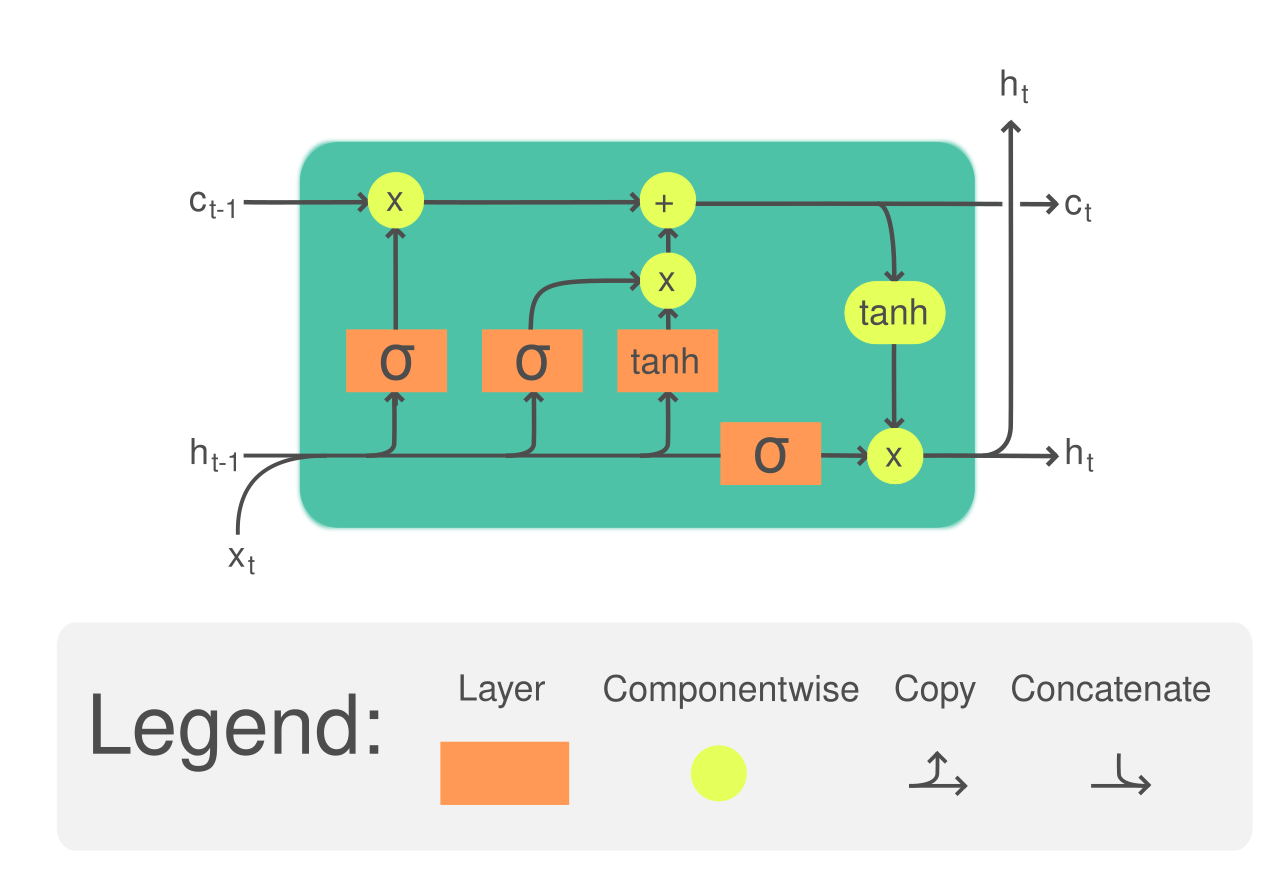
Imágen de [Wikipedia](https://en.wikipedia.org/wiki/Long_short-term_memory)

Dado un paso de tiempo `t`, la LSTM recibe como entrada:

- `x_t`: el vector de entrada en el tiempo `t`
- `h_{t-1}`: el estado oculto del tiempo anterior
- `c_{t-1}`: el estado de la celda (memoria) anterior

#### Parámetros:
- `W`, `U`, `b`: matrices de pesos y vectores de sesgo para cada puerta (a veces con subíndices f, i, o, c)

#### Ecuaciones:

1. **Puerta de olvido** (forget gate): decide qué parte de la memoria olvidar
   
   $
   f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
   $

2. **Puerta de entrada** (input gate): decide qué nueva información agregar a la memoria
   
   $
   i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
   $
   
   $
   c_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
   $

3. **Actualización de la celda** (nuevo estado de memoria):
   
   $
   c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
   $

4. **Puerta de salida** (output gate): decide qué parte de la memoria usar como salida oculta
   
   $
   o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
   $

   $
   h_t = o_t \odot \tanh(c_t)
   $

Donde:
- $\sigma$ es la función sigmoide: $\sigma(x) = \frac{1}{1 + e^{-x}}$
- $tanh$ es la tangente hiperbólica
- $\odot$ denota el producto elemento a elemento (*Hadamard product*)

#### Intuición:
- La **puerta de olvido** controla cuánto del estado anterior mantener.
- La **puerta de entrada** regula cuánto de la nueva información agregar a la memoria.
- La **puerta de salida** decide qué parte de la memoria revelar como salida.
- Este mecanismo permite **preservar gradientes** y **mitigar el desvanecimiento del gradiente**, que es común en las RNN clásicas.

Gracias a esta estructura, las LSTM pueden aprender patrones secuenciales complejos y relaciones a largo plazo, como en tareas de traducción, texto, o sumas simbólicas como en tu ejemplo.


In [ ]:
i = Input((MAXLEN, len(chars)))
d = LSTM(128, return_sequences=False)(i)
d = RepeatVector(DIGITS+1)(d)
d = LSTM(128, return_sequences=True)(d)
d = Dense(len(chars), activation='softmax')(d)

model = Model(i, d)
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 7, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4, 12)          │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,324 (802.05 KB)

 Trainable params: 205,324 (802.05 KB)

 Non-trainable params: 0 (0.00 B)

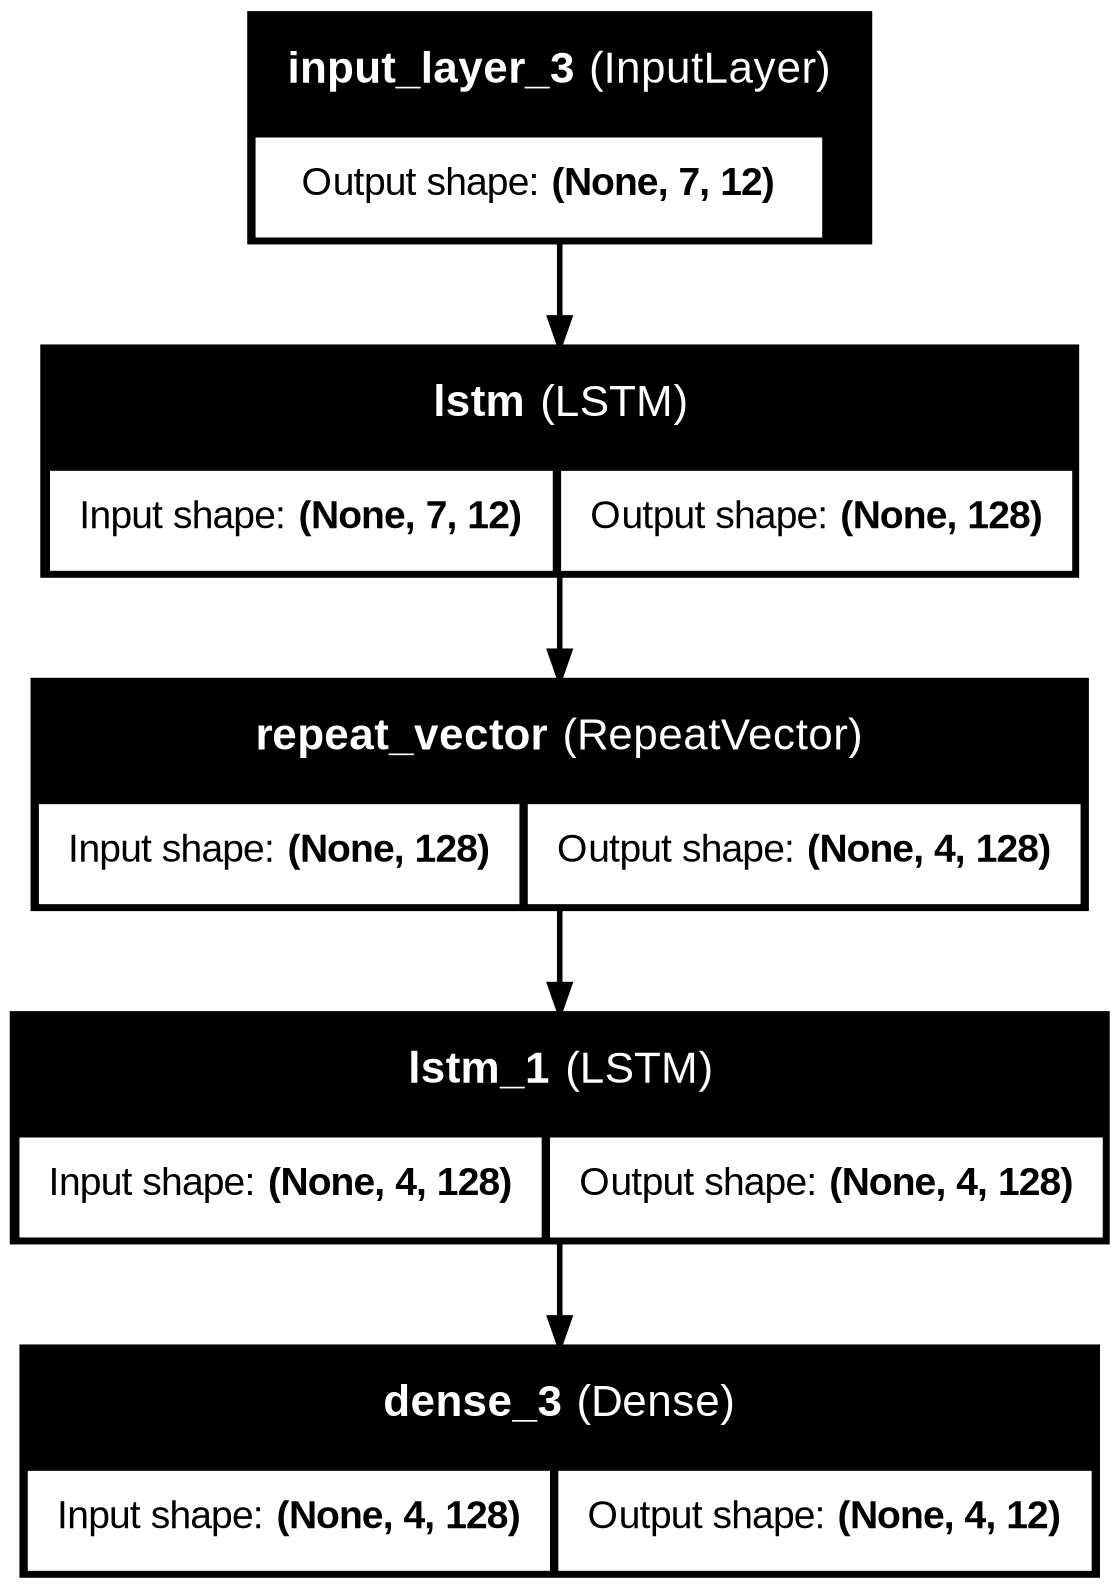

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
Image(retina=True, filename='model.png')

### Entrenamiento del Modelo y Visualización de Resultados

Este bloque entrena el modelo usando los datos generados, durante un número definido de épocas (`epochs = 15`) y con un tamaño de lote (`batch_size = 32`). En cada iteración del bucle principal (una época), se entrena el modelo una sola vez con `model.fit`, utilizando los datos de entrenamiento (`x_train`, `y_train`) y validando contra `x_val`, `y_val`.

Después de cada época, se seleccionan **10 ejemplos aleatorios del conjunto de validación** para mostrar predicciones del modelo. Para cada ejemplo:

- Se extrae una entrada (`rowx`) y su salida esperada (`rowy`)
- El modelo realiza una predicción (`model.predict(rowx)`)
- Se decodifican la entrada (`q`), la salida correcta (`correct`) y la salida predicha (`guess`) a texto, usando la clase `CharacterTable`
- Se imprime la operación original (`Q`), el resultado esperado (`T`), y si la predicción fue correcta o no, con un símbolo:
  - ☑ si la predicción es correcta
  - ☒ si es incorrecta

Este ciclo permite visualizar cómo mejora el desempeño del modelo en cada época y analizar sus errores de forma concreta y comprensible.


In [ ]:
epochs = 15 #30
batch_size = 32


# Train the model each generation and show predictions against the validation
# dataset.
for epoch in range(1, epochs):
    print()
    print("Iteration", epoch)
    model.fit(
        x_train,
        y_train,
        batch_size=batch_size,
        epochs=1,
        validation_data=(x_val, y_val),
    )
    # Select 10 samples from the validation set at random so we can visualize
    # errors.
    for i in range(10):
        ind = np.random.randint(0, len(x_val))
        rowx, rowy = x_val[np.array([ind])], y_val[np.array([ind])]
        preds = np.argmax(model.predict(rowx), axis=-1)
        q = ctable.decode(rowx[0])
        correct = ctable.decode(rowy[0])
        guess = ctable.decode(preds[0], calc_argmax=False)
        print("Q", q[::-1] if REVERSE else q, end=" ")
        print("T", correct, end=" ")
        if correct == guess:
            print("☑ " + guess)
        else:
            print("☒ " + guess)


Iteration 1
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.3523 - loss: 1.7697 - val_accuracy: 0.4052 - val_loss: 1.5756
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Q 287+669 T 956  ☒ 804 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Q 181+892 T 1073 ☒ 102 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Q 27+589  T 616  ☒ 704 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Q 179+836 T 1015 ☒ 904 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Q 38+259  T 297  ☒ 334 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Q 847+46  T 893  ☒ 804 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Q 346+636 T 982  ☒ 1044
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Q 3+437   T 440  ☒ 439 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Q 853+115 T 968  ☒ 1024
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Q 451+13  T 464  ☒ 504 

Iteration 2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.4751 - loss: 1.3969 - val_accuracy: 0.5163 - val_loss: 1.2777
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Q 592+806 T 1398 ☒ 1332
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Q 66+935  T 

## 🎬IMDB: Analisis de sentimientos 😃😟

### Dataset IMDb (Internet Movie Database)

El dataset IMDb es un conjunto de datos clásico utilizado en tareas de **clasificación de sentimientos** en procesamiento de lenguaje natural (NLP). Fue preparado por Andrew Maas y su equipo, y se utiliza comúnmente para entrenar y evaluar modelos de clasificación binaria sobre texto.

#### Características principales:

- **Dominio:** Reseñas de películas extraídas del sitio IMDb.
- **Tamaño:**
  - 50,000 reseñas en total.
  - 25,000 para entrenamiento y 25,000 para prueba.
- **Etiquetas:**
  - `1` (positivo): si la reseña refleja una opinión favorable sobre la película.
  - `0` (negativo): si la reseña refleja una opinión desfavorable.
- **Balanceado:** El conjunto está balanceado: 50% de reseñas positivas y 50% negativas.
- **Formato:**
  - Cada reseña es un archivo `.txt` dentro de un directorio:
    - `aclImdb/train/pos/` y `aclImdb/train/neg/`
    - `aclImdb/test/pos/` y `aclImdb/test/neg/`
  - Los textos son en inglés y varían en longitud (desde pocas frases hasta párrafos largos).

#### Uso típico:
Este dataset se usa para construir modelos que puedan **predecir automáticamente si una reseña es positiva o negativa**, basándose en el contenido del texto. Se ha utilizado ampliamente para comparar modelos clásicos (como Naive Bayes o SVM) y modernos (como LSTM, GRU, transformers, etc.).

#### Ejemplo de reseña:
```text
This movie was a wonderful surprise. The performances were heartfelt and the story was engaging from start to finish. Highly recommended!
→ Etiqueta: 1 (positivo)




In [ ]:
!wget -nc https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz

--2026-09-09 22:57:31--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  19.6MB/s    in 5.6s    

2026-09-09 22:57:37 (14.4 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



In [ ]:
def load_imdb_ds(path, shuffle_ds=True, random_state=None):
    def load_text(path_sel):
        xa = []
        for f in os.listdir(path_sel):
            f = open(path_sel + os.sep + f, 'r')
            xa.append(next(f))
        return xa
    x = load_text(path + os.sep + 'pos')
    y = [1] * len(x)
    xn = load_text(path + os.sep + 'neg')
    x.extend(xn)
    y.extend([0] * len(xn))
    if shuffle_ds:
        shuffle(x, y, random_state=random_state)
    return x, y

x_train_text, y_train = load_imdb_ds('aclImdb/train', random_state=42)
x_test_text, y_test = load_imdb_ds('aclImdb/test', random_state=42)

In [ ]:
x_train_text[:2]

['As a big-time Prince fan of the last three to four years, I really can\'t believe I\'ve only just got round to watching "Purple Rain". The brand new 2-disc anniversary Special Edition led me to buy it. Wow, I was really looking forward to watching it, but I wasn\'t prepared for just how electric it actually is. Prince\'s musical performances throughout the movie are nothing short of astounding - he REALLY has the moves in this one. I am very familiar (from repeated listens) with the classic "Purple Rain" album and all its songs, but to see them in the context of the movie completely alters your perception of the tunes and lyrics - like COMPUTER BLUE, THE BEAUTIFUL ONES, WHEN DOVES CRY and PURPLE RAIN itself. There is something indescribably hypnotising about the scenes where Prince and The Revolution perform. The closing songs BABY I\'M A STAR and I WOULD DIE FOR U show how much energy and sheer talent Prince was brimming with in his mid-20s (he\'s overflowing!), it blew me away. It 

### Preprocesamiento y Tokenización del Texto (IMDb) 🎬

Este conjunto de funciones permite preparar texto crudo (como reseñas de películas del dataset IMDb) para ser utilizado en modelos de procesamiento de lenguaje natural. El flujo general incluye **limpieza de texto**, **tokenización**, **opcionalmente aplicar stemming**, y convertir las palabras en IDs numéricos.

---

#### `preprocessor(text)`

- Elimina etiquetas HTML usando `BeautifulSoup`.
- Extrae y preserva emoticones (`:)`, `:-P`, etc.) usando expresiones regulares.
- Convierte el texto a minúsculas, elimina caracteres no alfabéticos (`\W`) y coloca los emoticones al final.
- Resultado: texto limpio y normalizado en minúsculas.

---

#### `tokenizer_stem_nostop(text)`

- Aplica stemming con `PorterStemmer` para reducir las palabras a su raíz.
- Elimina *stopwords* (palabras comunes sin carga semántica, como "the", "is") si están en la lista `stop`.
- Devuelve una lista de tokens (palabras reducidas).

---

#### `tokenizer_simple(text)`

- Divide el texto en palabras por espacios.
- Filtra únicamente palabras alfabéticas (`[a-zA-Z]+`).
- No aplica stemming ni eliminación de stopwords.

---

#### `process_corpus(data, words_id=None, min_reps=5, tokenizer=tokenizer_simple)`

Esta función convierte una lista de documentos en secuencias de IDs de palabras.

1. **Tokenización**:
   - Aplica `preprocessor` y luego la función de tokenización seleccionada (`tokenizer_simple` por defecto) a cada documento.

2. **Construcción del vocabulario**:
   - Si no se proporciona un vocabulario (`words_id`), cuenta la frecuencia de cada palabra.
   - Elimina las palabras con menos de `min_reps` apariciones (por defecto, 5).
   - Asigna un ID entero a cada palabra conservada (`words_id`).

3. **Codificación**:
   - Cada documento se transforma en una lista de IDs (`corpus_id`) usando `words_id`.

4. Devuelve:
   - `corpus_id`: lista de listas con IDs de palabras.
   - `words_id`: diccionario de palabra → ID.
   - `id_words`: diccionario inverso ID → palabra.


In [ ]:
def preprocessor(text):
    # remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text()

    # regex for matching emoticons, keep emoticons, ex: :), :-P, :-D
    r = r'(?::|;|=|X)(?:-)?(?:\)|\(|D|P)'
    emoticons = re.findall(r, text)
    text = re.sub(r, '', text)

    # convert to lowercase and append all emoticons behind (with space in between)
    # replace('-','') removes nose of emoticons
    text = re.sub(r'[\W]+', ' ', text.lower()) + ' ' + ' '.join(emoticons).replace('-','')
    return text



def tokenizer_stem_nostop(text):
    porter = PorterStemmer()
    return [porter.stem(w) for w in re.split(r'\s+', text.strip()) \
            if w not in stop and re.match(r'[a-zA-Z]+', w)]


def tokenizer_simple(text):
    return [w for w in re.split(r'\s+', text.strip()) \
            if re.match(r'[a-zA-Z]+', w)]


def process_corpus(data, words_id=None, min_reps=5, tokenizer=tokenizer_simple):
    corpus = []
    for text in tqdm(data):
        corpus.append(tokenizer(preprocessor(text)))

    if words_id is None:
        #Cuenta palabras en el corpus
        words = Counter()

        for s in corpus:
            for w in s:
                words[w] += 1

        #Elimina palabras con menos de 5 repeticiones
        words_id = {}
        id_next = 1
        for w, c in words.items():
            if c >= min_reps:
                words_id[w] = id_next
                id_next += 1

    id_words = { v:k for k, v in words_id.items()}
    corpus_id = [[words_id[w] for w in s if w in words_id] for s in corpus]
    return corpus_id, words_id, id_words

In [ ]:
x_train, words_id, id_words = process_corpus(x_train_text)
x_test, _, _ = process_corpus(x_test_text, words_id=words_id)
y_train = np.expand_dims(np.asarray(y_train), axis=-1)
y_test = np.expand_dims(np.asarray(y_test), axis=-1)

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
id_words

{1: 'as',
 2: 'a',
 3: 'big',
 4: 'time',
 5: 'prince',
 6: 'fan',
 7: 'of',
 8: 'the',
 9: 'last',
 10: 'three',
 11: 'to',
 12: 'four',
 13: 'years',
 14: 'i',
 15: 'really',
 16: 'can',
 17: 't',
 18: 'believe',
 19: 've',
 20: 'only',
 21: 'just',
 22: 'got',
 23: 'round',
 24: 'watching',
 25: 'purple',
 26: 'rain',
 27: 'brand',
 28: 'new',
 29: 'disc',
 30: 'anniversary',
 31: 'special',
 32: 'edition',
 33: 'led',
 34: 'me',
 35: 'buy',
 36: 'it',
 37: 'wow',
 38: 'was',
 39: 'looking',
 40: 'forward',
 41: 'but',
 42: 'wasn',
 43: 'prepared',
 44: 'for',
 45: 'how',
 46: 'electric',
 47: 'actually',
 48: 'is',
 49: 's',
 50: 'musical',
 51: 'performances',
 52: 'throughout',
 53: 'movie',
 54: 'are',
 55: 'nothing',
 56: 'short',
 57: 'astounding',
 58: 'he',
 59: 'has',
 60: 'moves',
 61: 'in',
 62: 'this',
 63: 'one',
 64: 'am',
 65: 'very',
 66: 'familiar',
 67: 'from',
 68: 'repeated',
 69: 'listens',
 70: 'with',
 71: 'classic',
 72: 'album',
 73: 'and',
 74: 'all',
 75: 

In [ ]:
for i in range(3):
    print(f"Ejemplo {i+1}:")
    print("Texto original:")
    print(x_train_text[i])
    print("\nTokens:")
    print(x_train[i])

    print("\nRebuild:")
    print([id_words[x] for x in x_train[i]])
    print("\n" + "="*50 + "\n")

Ejemplo 1:
Texto original:
As a big-time Prince fan of the last three to four years, I really can't believe I've only just got round to watching "Purple Rain". The brand new 2-disc anniversary Special Edition led me to buy it. Wow, I was really looking forward to watching it, but I wasn't prepared for just how electric it actually is. Prince's musical performances throughout the movie are nothing short of astounding - he REALLY has the moves in this one. I am very familiar (from repeated listens) with the classic "Purple Rain" album and all its songs, but to see them in the context of the movie completely alters your perception of the tunes and lyrics - like COMPUTER BLUE, THE BEAUTIFUL ONES, WHEN DOVES CRY and PURPLE RAIN itself. There is something indescribably hypnotising about the scenes where Prince and The Revolution perform. The closing songs BABY I'M A STAR and I WOULD DIE FOR U show how much energy and sheer talent Prince was brimming with in his mid-20s (he's overflowing!), i

### Padding de Secuencias

Para que las secuencias de palabras tengan una longitud fija y puedan ser procesadas en batch por modelos como LSTM o redes neuronales, es necesario que todas tengan la misma longitud.

En este caso, se define una longitud máxima `MAXLEN = 50`. Luego, se usa la función `pad_sequences` de Keras para:

- **`x_train` y `x_test`**: listas de secuencias (listas de IDs de palabras) de longitud variable.
- Se rellenan las secuencias más cortas con ceros al final (`padding='post'`).
- Las secuencias más largas se recortan para ajustarse a la longitud máxima de 50.

Esto garantiza que todas las entradas al modelo tengan exactamente 50 tokens, facilitando el entrenamiento y la inferencia.

---

#### Ejemplo simple de padding

Supongamos que tenemos estas dos secuencias de IDs de palabras:

```python
sequences = [
    [5, 12, 7],
    [3, 9]
]
```

Si aplicamos padding con longitud máxima `5` y `padding='post'`, obtenemos:

```python
[
    [5, 12, 7, 0, 0],
    [3, 9, 0, 0, 0]
]
```

Aquí, los ceros actúan como relleno para que todas las secuencias tengan la misma longitud, y no afecten el aprendizaje del modelo si se usan correctamente.

In [ ]:
MAXLEN = 50

x_train = pad_sequences(x_train, maxlen=MAXLEN, padding='post')
x_test = pad_sequences(x_test, maxlen=MAXLEN, padding='post')

In [ ]:
print(x_train.shape)
print(x_train[180:, :])

(25000, 50)
[[  569  1046    73 ...   584  1054   355]
 [ 6477    58  1801 ...    61   245   330]
 [   22     8  1005 ...    49    88  5322]
 ...
 [24670   294    73 ...  1943    44  1191]
 [   73   182   136 ...    11   129   908]
 [   82     4   503 ...   605 14457    36]]


### 🤔Explicación de la Capa Embedding

La capa de *embedding* convierte índices enteros que representan palabras en vectores densos de dimensión fija. Supongamos que el vocabulario tiene tamaño $ V $ y la dimensión del embedding es $ D $. Esta capa aprende una matriz de pesos $ W \in \mathbb{R}^{V \times D} $, donde cada fila $ W_i $ es el vector embedding de la palabra con índice $ i $.

Cuando una palabra está representada por un índice $ i $, la capa embedding devuelve directamente la fila $ W_i $. Esto es equivalente a multiplicar un vector one-hot $ \mathbf{x} \in \{0,1\}^V $ (con un 1 en la posición $ i $ y ceros en el resto) por la matriz $ W $:

$
\mathbf{e} = \mathbf{x}^\top W = W_i
$

Sin embargo, en vez de realizar esta multiplicación completa, la capa embedding recupera directamente la fila correspondiente, lo que es mucho más eficiente.

Esta representación permite que el modelo aprenda vectores densos que capturan propiedades semánticas y sintácticas de las palabras, a diferencia de los vectores one-hot que son dispersos y no contienen información sobre similitud.

Finalmente, al usar esta capa en conjunto con redes recurrentes LSTM, se facilita la captura de dependencias contextuales en secuencias de texto, mejorando el rendimiento en tareas como clasificación o generación de texto.

### 💡 Clasificando texto
Esta red está diseñada para resolver una tarea de clasificación binaria usando el dataset de reseñas de películas IMDB. En concreto, su objetivo es predecir si una reseña es positiva o negativa a partir del texto de la misma.

El proceso comienza convirtiendo cada reseña en una secuencia de índices que representan palabras del vocabulario. La capa de embedding transforma esos índices en vectores densos que capturan características semánticas de las palabras. Luego, las capas LSTM procesan estas secuencias para extraer patrones y dependencias contextuales a lo largo del texto, importantes para entender el sentimiento expresado. Los mecanismos de dropout aplicados antes y entre las LSTM ayudan a evitar que el modelo se sobreajuste a los datos de entrenamiento.

Finalmente, la capa densa con activación sigmoide produce una probabilidad entre 0 y 1 que indica la probabilidad de que la reseña sea positiva. El modelo se entrena minimizando la pérdida binaria de entropía cruzada, optimizando así su capacidad para distinguir correctamente entre opiniones positivas y negativas basándose en el contenido textual.


In [ ]:
i = Input((None,))
d = Embedding(len(words_id) + 1, 300, mask_zero=True)(i)
d = Dropout(0.5)(d)
d = LSTM(128, return_sequences=True)(d)
d = Dropout(0.5)(d)
d = LSTM(128, return_sequences=False)(d)
d = Dropout(0.5)(d)
d = Dense(1, activation='sigmoid')(d)

model = Model(i, d)
model.summary()
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['binary_accuracy'])

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 300) │  8,625,300 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 300) │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 128) │    219,648 │ dropout[0][0],    │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 128) │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 128)       │    131,584 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,976,661 (34.24 MB)

 Trainable params: 8,976,661 (34.24 MB)

 Non-trainable params: 0 (0.00 B)

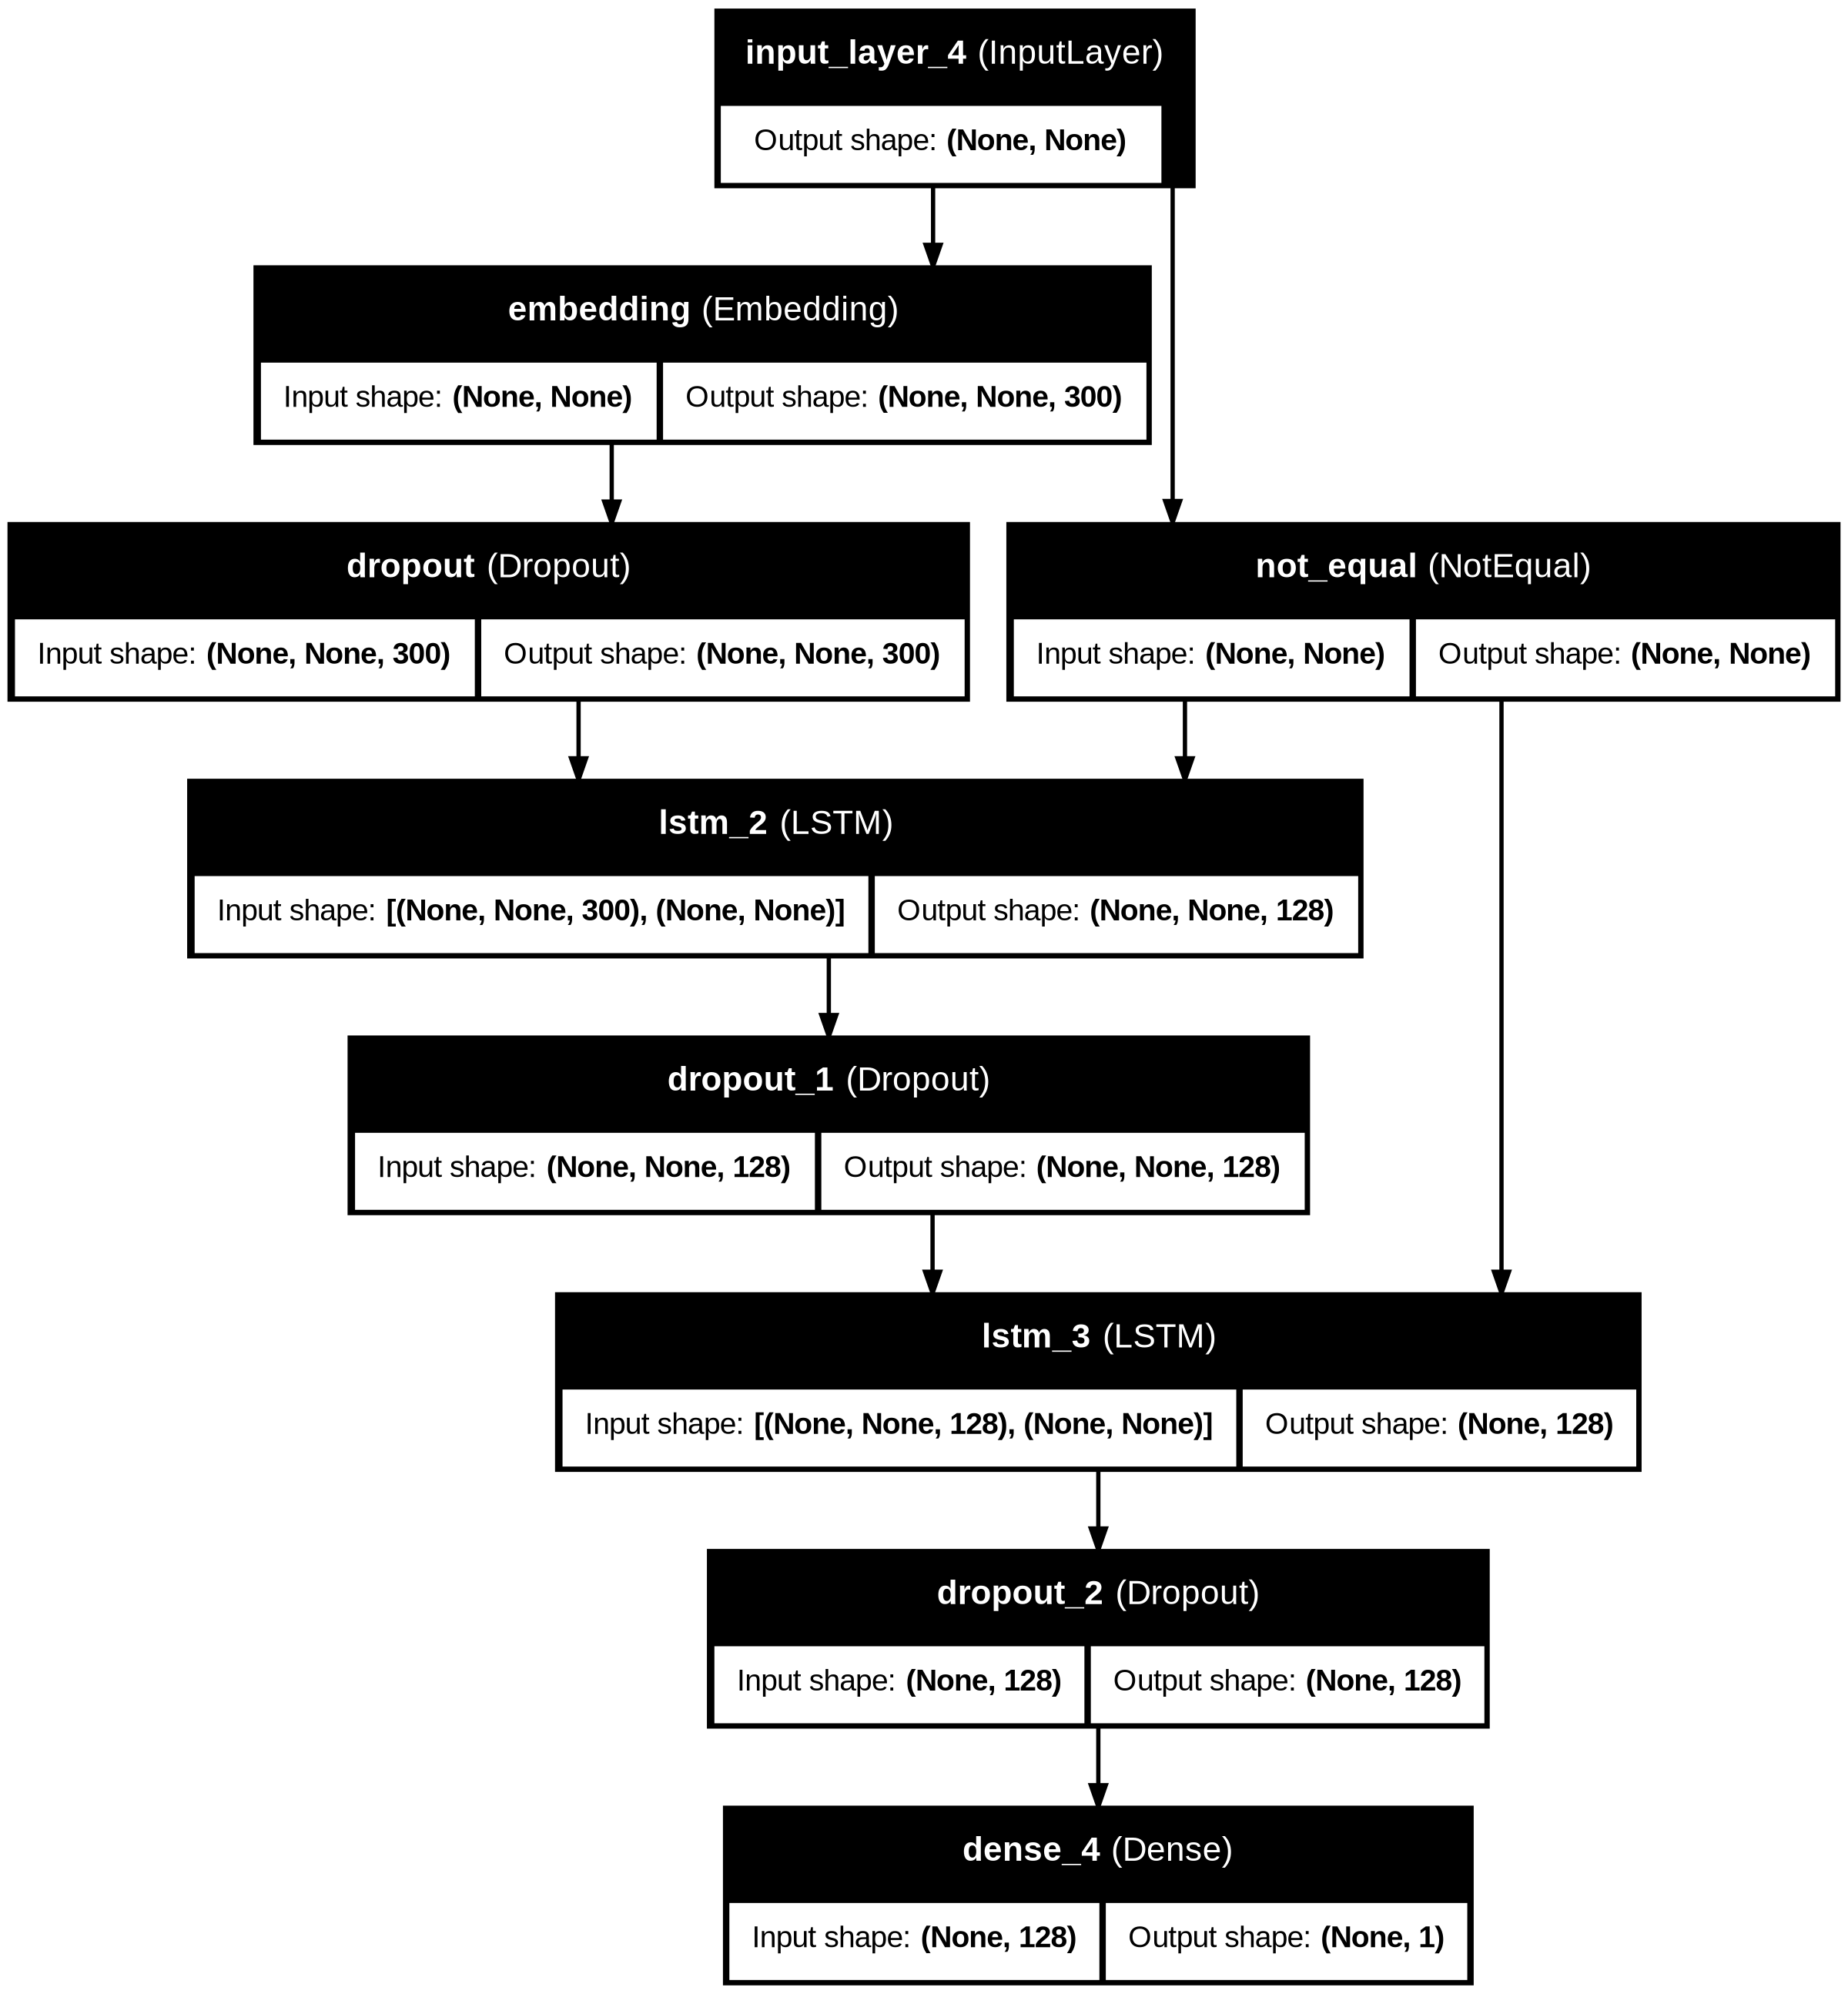

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
Image(retina=True, filename='model.png')

In [ ]:
model.fit(x_train, y_train, epochs=2, validation_data=(x_test, y_test))

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 500s 639ms/step - binary_accuracy: 0.7448 - loss: 0.5119 - val_binary_accuracy: 0.8005 - val_loss: 0.4502
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 499s 638ms/step - binary_accuracy: 0.8276 - loss: 0.3991 - val_binary_accuracy: 0.7704 - val_loss: 0.5480


In [ ]:
my_text, _, _ = process_corpus(['I really loved the movie. It was excelent',
                               'The movie was fine, but the music is terrible'], words_id=words_id)
print(my_text)
my_text = pad_sequences(my_text, maxlen=MAXLEN, padding='post')
print(model.predict(my_text))

  0%|          | 0/2 [00:00<?, ?it/s]

[[14, 15, 1141, 8, 53, 36, 38], [8, 53, 38, 1750, 41, 8, 1107, 48, 2918]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
[[0.8590525 ]
 [0.34063676]]


## 🗒️Entrenando nuestro GloVe

GloVe (Global Vectors for Word Representation) es un método para obtener representaciones vectoriales densas de palabras (embeddings) que capturan relaciones semánticas y contextuales basándose en la estadística global de coocurrencia de palabras en un corpus.

En lugar de usar solo ventanas locales, GloVe construye una matriz de coocurrencia $X$, donde cada elemento $X_{ij}$ indica cuántas veces aparece la palabra $j$ cerca de la palabra $i$. Luego, aprende vectores para las palabras que minimizan la diferencia entre el producto punto de sus vectores y el logaritmo de la frecuencia de coocurrencia, usando la función de pérdida:

$
J = \sum_{i,j=1}^V f(X_{ij}) \left( w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$

donde:

- $w_i$ y $\tilde{w}_j$ son los vectores de palabra y contexto respectivamente.
- $b_i$ y $\tilde{b}_j$ son términos de sesgo.
- $f$ es una función de ponderación que reduce la importancia de coocurrencias muy raras o muy frecuentes.

El resultado son vectores que capturan relaciones semánticas complejas, permitiendo realizar operaciones vectoriales útiles, como analogías semánticas.

GloVe es ampliamente usado para inicializar capas de embedding en modelos de procesamiento de lenguaje natural, aportando conocimiento semántico preentrenado que mejora el rendimiento del modelo.

La función de ponderación $f$ suele definirse como:

$f(x) =
\begin{cases}
\left(\frac{x}{x_{\max}}\right)^\alpha & \text{si } x < x_{\max} \\
1 & \text{en otro caso}
\end{cases}
$

con parámetros típicos $x_{\max} = 100$ y $\alpha = 0.75$.

En resumen, la función de pérdida fuerza a los vectores a representar de forma compacta las estadísticas globales de coocurrencia, aprendiendo relaciones semánticas útiles entre palabras.

---
⏱️ **2:12 — Bloque 6** (~11 min de código (co-ocurrencias, entrenamiento GloVe, embeddings preentrenados), ver guion para talking points detallados)

---

In [ ]:
x_train_list, _, _ = process_corpus(x_train_text, words_id=words_id)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
def build_cooccurrence_matrix(corpus, window_size=5):
    """
    Construye una matriz de coocurrencias en formato diccionario anidado:
    {palabra_i: {palabra_j: count, ...}, ...}

    Args:
        corpus: lista de listas de enteros (tokens).
        window_size: tamaño de la ventana de contexto a izquierda y derecha.

    Returns:
        cooccurrence: diccionario anidado con las coocurrencias.
    """
    cooccurrence = defaultdict(lambda: defaultdict(float))

    for sentence in tqdm(corpus):
        length = len(sentence)
        for idx, word in enumerate(sentence):
            start = max(0, idx - window_size)
            end = min(length, idx + window_size + 1)
            for ctx_idx in range(start, end):
                if ctx_idx != idx:
                    context_word = sentence[ctx_idx]
                    # Ponderar por la distancia (opcional)
                    distance = abs(ctx_idx - idx)
                    cooccurrence[word][context_word] += 1.0 / distance

    return cooccurrence


In [ ]:
# Ejemplo de uso con x_train_list
cooc_mat = build_cooccurrence_matrix(x_train_list, window_size=5)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
w_1 = np.concatenate([np.asarray([k] * len(x)) for k, x in cooc_mat.items()])
w_2 = np.concatenate([np.asarray(list(x.keys())) for x in cooc_mat.values()])
t = np.concatenate([np.asarray(list(x.values())) for x in cooc_mat.values()])

In [ ]:
for a, b, c in zip(w_1, w_2, t):
    if cooc_mat[a][b] != c:
        print(a, b, cooc_mat[a][b], c)
        break
else:
    print('OK')

OK


In [ ]:
vocab_size = len(words_id) + 1   # set appropriately
embedding_dim = 300
x_max = 100
alpha = 0.75

# Inputs (word and context indices)
w1_input = Input(shape=(1,), name='w1_input')
w2_input = Input(shape=(1,), name='w2_input')

# Embedding layers
w_embedding = Embedding(vocab_size, embedding_dim, name='word_embedding')
w_context_embedding = Embedding(vocab_size, embedding_dim, name='context_embedding')
w_bias = Embedding(vocab_size, 1, name='word_bias')
w_context_bias = Embedding(vocab_size, 1, name='context_bias')

# Dot product + bias
w_vec = w_embedding(w1_input)
w_context_vec = w_context_embedding(w2_input)
dot = Dot(axes=-1)([w_vec, w_context_vec])  # shape: (None, 1, 1)

bias_sum = Add()([w_bias(w1_input), w_context_bias(w2_input)])  # shape: (None, 1, 1)
dot_bias = Add()([dot, bias_sum])  # shape: (None, 1, 1)
dot_bias = Reshape((1,))(dot_bias)

# Build model
model = Model(inputs=[w1_input, w2_input], outputs=dot_bias)


# Custom loss
def glove_loss(y_true, y_pred):
    # y_true: log(count), y_pred: dot_bias
    log_y = ops.log(y_true)
    weight = ops.minimum(y_true / x_max, 1.0) ** alpha
    loss = weight * ops.square(y_pred - log_y)
    return ops.mean(loss)

# Compile
model.compile(loss=glove_loss, optimizer='adam')

In [ ]:
model.fit((w_1, w_2), t, batch_size=1024, epochs=2)

Epoch 1/2
9502/9502 ━━━━━━━━━━━━━━━━━━━━ 2193s 231ms/step - loss: 0.0521
Epoch 2/2
5954/9502 ━━━━━━━━━━━━━━━━━━━━ 14:00 237ms/step - loss: 0.0232

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
Image(retina=True, filename='model.png')

In [ ]:
embs = w_embedding.embeddings.numpy()
embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)

## 🔍 Búsqueda de Palabras Más Similares en un Espacio de Embeddings
La función find_most_similars permite identificar las palabras más cercanas semánticamente a una palabra dada, utilizando vectores de embeddings entrenados. Cada palabra está representada por un vector en un espacio de dimensión fija, y la similitud entre dos palabras se mide mediante el producto punto entre sus vectores.

Dado:

* Una palabra de entrada word.

* Diccionarios words_id y id_words que permiten mapear palabras a índices y viceversa.

* Una matriz de embeddings embs, donde cada fila es un vector de una palabra.

* Un parámetro top_n que indica cuántas palabras similares se desean recuperar.

### 🧮 Cálculo de similitud
Se obtiene el vector correspondiente a la palabra consultada:

$\overrightarrow{v}_{word}=embs[words\_id[word]]$

Luego se calcula su similitud con todas las demás palabras en el vocabulario:

$sim(\overrightarrow{v}_{word}, \overrightarrow{v}_{i})=\overrightarrow{v}_{word}\overrightarrow{v}_{i}$

Este producto punto equivale a la similitud coseno si los vectores están normalizados, es decir:

$\left\|\overrightarrow{v}_{i}\right\|=1,\quad \forall i$

Finalmente, se ordenan todas las palabras del vocabulario por su similitud con la palabra original (excluyéndola a sí misma), y se devuelven las top_n más similares, junto con su puntaje.

### 📌 Resultado
El resultado es una lista de tuplas con las palabras más similares a la dada y sus puntuaciones, lo cual permite explorar relaciones semánticas aprendidas por el modelo. Esto es útil, por ejemplo, para encontrar sinónimos, términos contextualmente relacionados o agrupamientos de significado.



In [ ]:
def find_most_similars(word, words_id, id_words, embs, top_n=10):
    if word not in words_id:
        print(f'Palabra {word} no encontrada')
        return
    word_id = words_id[word]
    sim = embs[word_id] @ embs.T
    ranking = np.argsort(sim)[::-1]
    return [(id_words[i], sim[i]) for i in ranking[1:top_n + 1]]

In [ ]:
words_id['batman']

In [ ]:
find_most_similars('batman', words_id, id_words, embs)

In [ ]:
glove = {k: embs[i, :] for k, i in words_id.items()}

## Embeddings preentrenados

In [ ]:
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

In [ ]:
!head glove.6B.300d.txt

In [ ]:
glove = {}
with open('glove.6B.300d.txt', 'r') as f:
    for line in f:
        line = line[:-1].split(' ')
        glove[line[0]] = np.asarray(list(map(float,line[1:])), dtype=np.float32)

In [ ]:
emb = Embedding(len(words_id) + 1, 300, mask_zero=True, trainable=False)
i = Input((None,))
d = emb(i)
d = Dropout(0.5)(d)
d = LSTM(128, return_sequences=True)(d)
d = Dropout(0.5)(d)
d = LSTM(128, return_sequences=False)(d)
d = Dropout(0.5)(d)
d = Dense(1, activation='sigmoid')(d)

model = Model(i, d)
model.summary()
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['binary_accuracy'])

In [ ]:
base_emb = np.zeros(emb.embeddings.shape)

added = 0
for w, i in words_id.items():
    if w in glove:
        added += 1
        base_emb[i, :] = glove[w]

#K.set_value(emb.embeddings, base_emb)
emb.embeddings.assign(base_emb)
#emb.trainable = False

print(f'Palabras con embeddings {added * 100 / len(words_id)}%')
#del emb

In [ ]:
base_emb

In [ ]:
emb.embeddings

In [ ]:
del emb
del base_emb
del glove

In [ ]:
model.fit(x_train, y_train, epochs=2, validation_data=(x_test, y_test))

## Generacion de texto

---
⏱️ **2:23 — Bloque 7** (~28 min de código: generación autoregresiva con sampling y temperatura, más Beam Search al final — ver guion para talking points detallados)

---


# 🧠 Entrenamiento de una red LSTM para generar texto carácter por carácter

Este código entrena una red neuronal recurrente (LSTM) para **predecir la siguiente letra en una secuencia de texto**. Utiliza un corpus literario (en este caso, *Martín Fierro*) para aprender patrones lingüísticos, letra por letra.

## 📥 Preparación del corpus

Se descarga el texto desde [Project Gutenberg](https://www.gutenberg.org/), se convierte a minúsculas y se extrae el conjunto de caracteres únicos presentes en el texto. A cada carácter se le asigna un índice:

$
\text{char_indices}: c \mapsto i, \quad \text{indices_char}: i \mapsto c
$

Luego se crean secuencias de texto de longitud fija `maxlen = 40`, avanzando cada `step = 3` caracteres. Por cada secuencia $ s = (c_1, c_2, ..., c_{40}) $, se guarda también el carácter siguiente $ c_{41} $ como objetivo de predicción. Esto forma un conjunto de entrenamiento del tipo:

$
\textbf{x}_i = \text{secuencia de 40 caracteres (one-hot)}, \quad y_i = \text{carácter siguiente (one-hot)}
$

## 🔢 Vectorización

Las secuencias y caracteres objetivo se codifican como vectores one-hot. La entrada `x` tiene forma `(n_secuencias, 40, n_caracteres)`, y la salida `y` es `(n_secuencias, n_caracteres)`.

## 🧱 Construcción del modelo

Se utiliza una red neuronal compuesta por:

1. Una capa **LSTM** con 128 unidades que procesa la secuencia de entrada.
2. Una capa **densa** con activación `softmax`, que predice la probabilidad de cada carácter posible como siguiente carácter.

La red se entrena con función de pérdida de **entropía cruzada categórica** y optimizador **Adam**.

## 🧪 Generación de texto

Después de cada época, se genera texto automáticamente a partir de una semilla de 40 caracteres tomada al azar del corpus. El modelo predice el siguiente carácter y lo agrega a la secuencia, repitiendo este proceso varias veces para construir texto nuevo.

La función `sample()` ajusta la aleatoriedad de la generación mediante un parámetro **diversity** o temperatura $ \tau $, aplicado así:

$
p_i = \frac{e^{\log(\hat{p}_i) / \tau}}{\sum_j e^{\log(\hat{p}_j) / \tau}}
$

- Valores bajos de $ \tau $ (e.g. 0.2) hacen que el modelo elija siempre los caracteres más probables → texto más repetitivo.
- Valores altos de $ \tau $ (e.g. 1.2) generan texto más creativo, pero también más ruidoso.

## ⚠️ Consideraciones

Este modelo aprende carácter por carácter, lo cual es más difícil que predecir palabra por palabra, ya que el contexto es más fragmentado. Además, la tarea de **predecir el siguiente carácter** en secuencias de texto requiere una **gran cantidad de datos** para aprender patrones coherentes de lenguaje.

Por ejemplo, generar oraciones gramaticales, rimas o estilos literarios solo es posible cuando el modelo ha visto suficientes ejemplos de ese estilo. Entrenar con textos breves o con un vocabulario limitado resulta en un modelo que produce texto poco coherente o repetitivo.


In [ ]:
# path = get_file(
#     'nietzsche.txt',
#     origin='https://s3.amazonaws.com/text-datasets/nietzsche.txt')

path = get_file(
    'martin.txt',
    origin='https://www.gutenberg.org/cache/epub/14765/pg14765.txt')
with io.open(path, encoding='utf-8') as f:
    text = f.read().lower()
print('corpus length:', len(text))

chars = sorted(list(set(text)))
print('total chars:', len(chars))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

# cut the text in semi-redundant sequences of maxlen characters
maxlen = 40
step = 3
sentences = []
next_chars = []
for i in range(0, len(text) - maxlen, step):
    sentences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])
print('nb sequences:', len(sentences))

print('Vectorization...')
x = np.zeros((len(sentences), maxlen, len(chars)), dtype=bool)
y = np.zeros((len(sentences), len(chars)), dtype=bool)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1


# Constir el modelo
print('Build model...')
i = Input((maxlen, len(chars)))
d = LSTM(128)(i)
d = Dense(len(chars), activation='softmax')(d)

model = Model(i, d)

optimizer = 'adam'
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


def sample(preds, temperature=1.0):
    # helper function to sample an index from a probability array
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def on_epoch_end(epoch, _):
    # Function invoked at end of each epoch. Prints generated text.
    print()
    print('----- Generating text after Epoch: %d' % epoch)

    start_index = random.randint(0, len(text) - maxlen - 1)
    for diversity in [0.2, 0.5, 1.0, 1.2]:
        print('----- diversity:', diversity)

        generated = ''
        sentence = text[start_index: start_index + maxlen]
        generated += sentence
        print('----- Generating with seed: "' + sentence + '"')
        sys.stdout.write(generated)

        for i in range(60):
            x_pred = np.zeros((1, maxlen, len(chars)))
            for t, char in enumerate(sentence):
                x_pred[0, t, char_indices[char]] = 1.

            preds = model.predict(x_pred, verbose=0)[0]
            next_index = sample(preds, diversity)
            next_char = indices_char[next_index]

            generated += next_char
            sentence = sentence[1:] + next_char

            sys.stdout.write(next_char)
            sys.stdout.flush()
        print()

print_callback = LambdaCallback(on_epoch_end=on_epoch_end)

model.fit(x, y,
          batch_size=128,
          epochs=10,
          callbacks=[print_callback])

90822/90822 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
corpus length: 85754
total chars: 73
nb sequences: 28572
Vectorization...
Build model...
Epoch 1/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1403 - loss: 3.3751
----- Generating text after Epoch: 0
----- diversity: 0.2
----- Generating with seed: "otro...
y si había venido en potro,
en r"
otro...
y si había venido en potro,
en re   o  a a e   r    e    e r  e e e     e         o    a   o
----- diversity: 0.5
----- Generating with seed: "otro...
y si había venido en potro,
en r"
otro...
y si había venido en potro,
en r b   o    e mue e an a es   aii doo l  e c agte o tnnaeae ca
----- diversity: 1.0
----- Generating with seed: "otro...
y si había venido en potro,
en r"
otro...
y si había venido en potro,
en rsth mrssi da rq 8edvs eacwalqeoqhóa ces eiure,o
ti.,a2e eeea
----- diversity: 1.2
----- Generating with seed: "otro...
y si había venido en potro,
en r"
otro...
y si había venido en potro,
en rufec aa eérr0osoce0*ayou ; ta 

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
Image(retina=True, filename='model.png')

## Beam Search: generación determinística

---
⏱️ Bloque 7 (continuación) — comparación entre *sampling* con temperatura (arriba) y **Beam Search**.

---

El `sample()` de arriba es **estocástico**: la misma semilla puede dar salidas distintas en cada corrida. Beam Search es la alternativa **determinística**: en vez de tirar un dado ponderado por `preds`, en cada paso se conservan los `beam_width` caminos parciales con mayor probabilidad **acumulada** (suma de log-probabilidades), se descartan el resto, y se sigue expandiendo solo esos.

- `beam_width = 1` ⇒ Beam Search se reduce a **greedy decoding** (siempre el carácter más probable).
- `beam_width` grande ⇒ explora más caminos, pero cuesta más cómputo y en la práctica tiende a producir texto más genérico/repetitivo (no necesariamente "mejor" percibido).
- Normalizamos por longitud al elegir el camino final (`log_prob / len(texto)`) para no castigar sistemáticamente a las secuencias más largas.
- Esta implementación usa una ventana deslizante de `maxlen` caracteres (igual que el modelo de arriba) y no tiene un token `<e>` explícito de fin de secuencia — a diferencia del Beam Search "clásico" de las diapositivas (con `<s>`/`<e>`, pensado para traducción/Seq2Seq), acá generamos una cantidad fija de caracteres. El mecanismo de poda (conservar los *k* mejores caminos acumulados) es exactamente el mismo.

In [ ]:
def beam_search_generate(model, seed, char_indices, indices_char, maxlen, beam_width=3, n_steps=60):
    """Beam Search determinístico sobre el modelo de generación carácter a carácter.

    En cada paso se expanden los `beam_width` caminos activos probando cada carácter
    posible, y se conservan los `beam_width` caminos con mayor log-probabilidad
    acumulada (poda). Al final se elige el camino de mayor probabilidad, normalizada
    por longitud.
    """
    # cada beam: (texto_generado_hasta_ahora, ventana_actual_de_maxlen_chars, log_prob_acumulada)
    beams = [(seed, seed, 0.0)]

    for _ in range(n_steps):
        candidates = []
        for generated, window, log_prob in beams:
            x_pred = np.zeros((1, maxlen, len(char_indices)))
            for t, char in enumerate(window):
                x_pred[0, t, char_indices[char]] = 1.
            preds = model.predict(x_pred, verbose=0)[0]

            # poda local: solo los beam_width caracteres más probables por camino,
            # para no explorar los ~30 caracteres del vocabulario en cada expansión
            top_idx = np.argsort(preds)[-beam_width:]
            for idx in top_idx:
                next_char = indices_char[idx]
                new_log_prob = log_prob + np.log(preds[idx] + 1e-12)
                new_window = (window + next_char)[1:]
                candidates.append((generated + next_char, new_window, new_log_prob))

        # poda global: de todos los caminos candidatos, solo sobreviven los beam_width mejores
        candidates.sort(key=lambda c: c[2], reverse=True)
        beams = candidates[:beam_width]

    # elegimos el mejor camino final normalizando por longitud (evita penalizar secuencias largas)
    best_generated, _, best_log_prob = max(beams, key=lambda c: c[2] / len(c[0]))
    return best_generated, best_log_prob

In [ ]:
start_index = random.randint(0, len(text) - maxlen - 1)
seed = text[start_index: start_index + maxlen]
print('----- Seed:', repr(seed))
print()

for k in (1, 3, 10):
    generated, log_prob = beam_search_generate(
        model, seed, char_indices, indices_char, maxlen, beam_width=k, n_steps=80
    )
    print(f'----- beam_width={k} (log_prob total={log_prob:.1f})')
    print(generated)
    print()

----- Seed: 'al punto dese por muerto\nsi el alcalde l'

----- beam_width=1 (log_prob total=-118.9)
al punto dese por muerto
si el alcalde la me paros se paros se paros se paros se paros se paros se paros se paros se par

----- beam_width=3 (log_prob total=-119.3)
al punto dese por muerto
si el alcalde la me pertar
y en la me me el se pertar
y en la me me el se pertar
y en la me me 

----- beam_width=10 (log_prob total=-116.2)
al punto dese por muerto
si el alcalde la me the peros se the peros de the peros de the peros de the peros de the peros 



# 📚Lecturas recomendadas

* Hochreiter, S., & Schmidhuber, J. (1997). [Long short-term memory](https://doi.org/10.1162/neco.1997.9.8.1735). Neural computation, 9(8), 1735-1780.

* Pennington, J., Socher, R. and Manning, C.D., 2014, October. [Glove: Global vectors for word representation](https://aclanthology.org/D14-1162.pdf). In Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP) (pp. 1532-1543).

* [Keras: NLP](https://keras.io/examples/nlp/)

* [Predicción de tráfico con Keras](https://keras.io/examples/timeseries/timeseries_traffic_forecasting/)

* [Predicción de clima](https://keras.io/examples/timeseries/timeseries_weather_forecasting/)

## 📺 Video

* StatQuest [Long Short-Term Memory (LSTM), Clearly Explained](https://www.youtube.com/watch?v=YCzL96nL7j0)
